# Keister integral and alternative integrands

Author: Fred J. Hickernell

The Keister integral is one example of variance and variation reduction. A change of variables creates a whole family of integrands $h_a$ with the same integral. We choose $a$ to make the integrand flatter or the estimator more accurate.

Run with the course `qmcpy` kernel, or open a private working copy in Colab:

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/fjhickernell/MATH565Fall2026/blob/main/notebooks/applications/KeisterExample.ipynb)

In Colab, run the setup cell once and then continue in order. Save a copy in Drive to keep your changes.

$\newcommand{\vX}{\boldsymbol{X}}$

In [1]:
from pathlib import Path
import shutil
import subprocess
import sys
import time

NOTEBOOK_START_TIME = time.perf_counter()

colab = "google.colab" in sys.modules
if colab:
    print("Setting up this course's recorded classlib, QMCPy, and TeX; this may take several minutes …")
    course_checkout = Path("/content/MATH565Fall2026")
    if not course_checkout.exists():
        subprocess.run(
            [
                "git", "clone", "--quiet", "--depth", "1",
                "https://github.com/fjhickernell/MATH565Fall2026.git",
                str(course_checkout),
            ],
            check=True,
        )
    subprocess.run(
        [
            "git", "-C", str(course_checkout),
            "-c", "submodule.classlib.url=https://github.com/fjhickernell/HickernellAcademicLib.git",
            "-c", "submodule.qmcpy.url=https://github.com/QMCSoftware/qmcpy.git",
            "submodule", "update", "--init", "classlib", "qmcpy",
        ],
        check=True,
    )
    if shutil.which("latex") is None:
        subprocess.run(
            [
                "apt-get", "-qq", "install", "-y",
                "cm-super", "dvipng", "texlive-latex-extra",
                "texlive-latex-recommended",
            ],
            check=True,
        )
    subprocess.run(
        [
            sys.executable, "-m", "pip", "install", "-q",
            str(course_checkout / "classlib"),
            str(course_checkout / "qmcpy"),
        ],
        check=True,
    )
    print("Colab setup complete.")
    print("For faster repeated work, use the local `qmcpy` environment.")

## One target expectation, many proposal representations

We seek
\begin{gather*}
\mu=\int_{\mathbb R^d}\cos(\|\boldsymbol x\|)e^{-\|\boldsymbol x\|^2}\,\mathrm d\boldsymbol x
=\mathbb E_{\mathrm{tar}}[f(\boldsymbol X)],\\
\boldsymbol X\sim\operatorname{Norm}(\boldsymbol0,\mathsf I_d/2),\qquad
f(\boldsymbol x)=\pi^{d/2}\cos(\|\boldsymbol x\|).
\end{gather*}
Choose $\boldsymbol Z_a\sim\operatorname{Norm}(\boldsymbol0,\mathsf I_d/a^2)$. The proposal contribution is
\begin{align*}
g_a(\boldsymbol z)&=f(\boldsymbol z)\frac{\varrho_{\mathrm{tar}}(\boldsymbol z)}{\varrho_{\mathrm{prop},a}(\boldsymbol z)}\\
&=(2\pi)^{d/2}a^{-d}\cos(\|\boldsymbol z\|)
\exp\{-(1-a^2/2)\|\boldsymbol z\|^2\}.
\end{align*}
The original output is $Y=f(\boldsymbol X)$; the alternative is $\widetilde Y_a=g_a(\boldsymbol Z_a)$. Every $a>0$ gives $\mathbb E[\widetilde Y_a]=\mu$.

On the unit cube, let $\boldsymbol S_a(\boldsymbol u)=\bigl(\Phi^{-1}(u_j)/a\bigr)_{j=1}^d$. Define $h_a=g_a\circ\boldsymbol S_a$, so $\mu=\int_{[0,1]^d}h_a(\boldsymbol u)\,\mathrm d\boldsymbol u$. Writing $\boldsymbol q(\boldsymbol u)=\bigl(\Phi^{-1}(u_j)\bigr)_{j=1}^d$,
\begin{align*}
h_a(\boldsymbol u)&=(2\pi)^{d/2}a^{-d}
\cos(\|\boldsymbol q(\boldsymbol u)\|/a)
\exp\{-(2-a^2)\|\boldsymbol q(\boldsymbol u)\|^2/(2a^2)\}.
\end{align*}
The code's `keister_u` evaluates this cube integrand $h_a$.

- $0<a^2\le2$: $h_a$ is bounded. At $a=\sqrt2$, the proposal equals the target and $g_a=f$.
- $2<a^2<4$: $h_a$ is unbounded near the cube boundary but has finite variance. We use $a=1.6$ to explore this range.
- $a^2\ge4$: the variance is infinite.

Indeed,
\begin{align*}
\mathbb E[g_a(\boldsymbol Z_a)^2]
&=\frac{(2\pi)^{d/2}}{a^d}\int_{\mathbb R^d}
\cos^2(\|\boldsymbol z\|)
\exp\{-(2-a^2/2)\|\boldsymbol z\|^2\}\,\mathrm d\boldsymbol z.
\end{align*}
The Gaussian decay makes this finite precisely when $a^2<4$. At $a^2=4$, that decay disappears; the squared cosine cannot provide cancellation. Boundary singularity and infinite variance therefore have different thresholds.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate, special, stats
from scipy.stats import qmc
import qmcpy as qp

%matplotlib inline

def keister_u(u, a):
    u = np.atleast_2d(u)
    q = stats.norm.ppf(np.clip(u, np.finfo(float).eps, 1-np.finfo(float).eps))
    radius2 = np.sum(q*q, axis=1)
    d = u.shape[1]
    return (2*np.pi)**(d/2) * a**(-d) * np.cos(np.sqrt(radius2)/a) * np.exp(-(2-a*a)*radius2/(2*a*a))

def keister_exact(d):
    area = 2*np.pi**(d/2)/special.gamma(d/2)
    value, error = integrate.quad(lambda r: area*r**(d-1)*np.cos(r)*np.exp(-r*r), 0, np.inf, epsabs=1e-11)
    return value

assert np.isfinite(keister_exact(6))

## Which transformed integrand is flatter?

First look in one dimension. The curves all have the same integral even though their shapes differ.

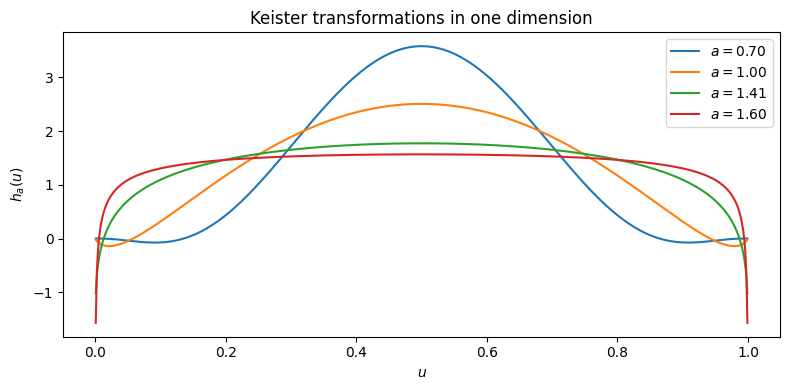

In [3]:
a_values = [0.7, 1.0, np.sqrt(2), 1.6]
u_grid = np.linspace(0.001, 0.999, 600)[:,None]
fig, ax = plt.subplots(figsize=(8,4))
for a in a_values:
    ax.plot(u_grid[:,0], keister_u(u_grid,a), label=rf"$a={a:.2f}$")
ax.set(xlabel="$u$", ylabel=r"$h_a(u)$", title="Keister transformations in one dimension")
ax.legend(); fig.tight_layout()

## Compare accuracy at the same sample size

Each row below uses independent replications. The randomized Sobol' and lattice points are dependent within a replication; the sample mean is unbiased because each point is uniform. The empirical RMSE is the square root of the mean squared error across replications relative to the radial-integration reference.

In [4]:
d, n, repetitions = 20, 2**14, 24
truth = keister_exact(d)
rows = []
for method in ["IID", "randomized Sobol", "randomized lattice"]:
    for a in a_values:
        estimates = []
        for rep in range(repetitions):
            seed = 2026 + rep
            if method == "IID":
                u = np.random.default_rng(seed).random((n,d))
            elif method == "randomized Sobol":
                u = qmc.Sobol(d, scramble=True, seed=seed).random_base2(int(np.log2(n)))
            else:
                u = qp.Lattice(d, seed=seed)(n)
            estimates.append(keister_u(u, a).mean())  # a is bound in this loop, not a late-bound lambda
        estimates = np.asarray(estimates)
        rows.append((method,a,estimates.mean(),np.sqrt(np.mean((estimates-truth)**2))))
print(f"Radial-integration reference: {truth:.8f}")
print("method                 a      mean        empirical RMSE")
for method,a,mean,rmse in rows:
    print(f"{method:21s} {a:5.2f} {mean:11.6f} {rmse:15.6f}")
assert all(np.isfinite(row[-1]) for row in rows)

Radial-integration reference: -82757.01080626
method                 a      mean        empirical RMSE
IID                    0.70 -91257.218362    39688.743472
IID                    1.00 -83907.293014     2704.831577
IID                    1.41 -82757.894888       94.483345
IID                    1.60 -82627.265372      544.274702
randomized Sobol       0.70 -82875.564889    31301.966403
randomized Sobol       1.00 -82929.753215     1140.197489
randomized Sobol       1.41 -82752.486991       19.849506
randomized Sobol       1.60 -82778.492212       79.860341
randomized lattice     0.70 -74616.624325    25424.788961
randomized lattice     1.00 -82789.340811     1110.801718
randomized lattice     1.41 -82760.941871       17.305805
randomized lattice     1.60 -82753.335331       95.135242


The best $a$ can depend on the sampling method and dimension. The $a=1.6$ case has an unbounded cube integrand but finite variance; finite variance alone does not guarantee a small empirical RMSE. Compare the observed errors across the equal-mean proposal contributions $g_a$ and their cube integrands $h_a$, rather than treat the Keister formula as one fixed estimator.


In [5]:
notebook_elapsed = time.perf_counter() - NOTEBOOK_START_TIME
notebook_minutes, notebook_seconds = divmod(notebook_elapsed, 60)
print(
    "Total execution time for this notebook is "
    f"{int(notebook_minutes)} min {notebook_seconds:.1f} sec."
)

Total execution time for this notebook is 0 min 3.8 sec.
